# Multi-task Transfer Learning for Multiclass Chest X-ray Diagnosis: Joint Lung Segmentation and COVID-19 Radiography Classification”
Authors:
Mohammed Abdulai
Peter Mvuma

# Libraries

In [1]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# Data Preprocessing

In [2]:
# Run the sanity check
import os

root = r"C:/Users/amysh/Desktop/AI_Project/covid19"

for cls in os.listdir(root):
    img_dir = os.path.join(root, cls, "images")
    msk_dir = os.path.join(root, cls, "masks")

    imgs = set(os.listdir(img_dir))
    masks = set(os.listdir(msk_dir))

    print(f"{cls}: images={len(imgs)}, masks={len(masks)}")

    missing = imgs - masks
    extra = masks - imgs

    if missing:
        print("  ❌ Missing masks:", list(missing)[:5])
    if extra:
        print("  ❌ Extra masks:", list(extra)[:5])


COVID: images=3616, masks=3616
Lung_Opacity: images=6012, masks=6012
Normal: images=10192, masks=10192
Viral_Pneumonia: images=1345, masks=1345


# Build the indexed dataset (image–mask–label)

In [3]:
import glob
import numpy as np

class_names = sorted(os.listdir(root))
class_to_idx = {c:i for i,c in enumerate(class_names)}

records = []

for cls in class_names:
    img_dir = os.path.join(root, cls, "images")
    msk_dir = os.path.join(root, cls, "masks")

    for img_path in sorted(glob.glob(img_dir + "\\*")):
        fname = os.path.basename(img_path)
        mask_path = os.path.join(msk_dir, fname)

        if os.path.exists(mask_path):
            records.append((img_path, mask_path, class_to_idx[cls]))

records = np.array(records, dtype=object)

print("Total samples:", len(records))
print("Class distribution:")
for c,i in class_to_idx.items():
    print(c, np.sum(records[:,2] == i))


Total samples: 21165
Class distribution:
COVID 3616
Lung_Opacity 6012
Normal 10192
Viral_Pneumonia 1345


# Stratified 70 / 15 / 15 split (Windows-safe)

In [4]:
from sklearn.model_selection import train_test_split

X = records[:, :2]     # image_path, mask_path
y = records[:, 2].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Val:  ", len(X_val))
print("Test: ", len(X_test))


Train: 14815
Val:   3175
Test:  3175


# Define constants + class names

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# If you already have this, keep yours:
class_names = ["COVID", "Lung_Opacity", "Normal", "Viral_Pneumonia"]
NUM_CLASSES = len(class_names)


# Define data augmentation (TRAIN ONLY)

In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name="data_augmentation")


# Create an image loader for baseline classification

This loads the raw image, resizes, rescales, and converts to 3-channel RGB-like.

In [7]:
def load_image_classification(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)  # grayscale
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0  # [0,1]
    img = tf.repeat(img, 3, axis=-1)        # (H,W,1) -> (H,W,3)

    y = tf.one_hot(label, depth=NUM_CLASSES)
    return img, y

# Augmentation wrapper (baseline)

In [8]:
def apply_augmentation_baseline(img, label):
    img = data_augmentation(img, training=True)
    return img, label


# Build baseline tf.data datasets (train gets augmentation)

X_train is shape (N,2) but for baseline we only need X[:,0] (image path)

In [9]:
def make_baseline_dataset(X, y, training=False):
    img_paths = X[:, 0].tolist()  # use ONLY image paths
    y = y.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((img_paths, y))
    ds = ds.map(load_image_classification, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(apply_augmentation_baseline, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(2048, seed=42, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_base = make_baseline_dataset(X_train, y_train, training=True)
val_ds_base   = make_baseline_dataset(X_val,   y_val,   training=False)
test_ds_base  = make_baseline_dataset(X_test,  y_test,  training=False)

# Sanity checks (shapes + augmentation is active)

In [10]:
# Shapes
imgs, labels = next(iter(train_ds_base))
print("Images:", imgs.shape)   # (B,224,224,3)
print("Labels:", labels.shape) # (B,4)

# Augmentation check (two different batches should differ)
imgs1, _ = next(iter(train_ds_base))
imgs2, _ = next(iter(train_ds_base))
print("Mean pixel difference:", tf.reduce_mean(tf.abs(imgs1 - imgs2)).numpy())


Images: (32, 224, 224, 3)
Labels: (32, 4)
Mean pixel difference: 0.22894543


# Baseline Model — ResNet121

In [11]:
def build_resnet_baseline(num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=(224,224,3))

    base = keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )
    base.trainable = False  # baseline = frozen

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="ResNet50_Baseline")
    return model

baseline_model = build_resnet_baseline(NUM_CLASSES)
baseline_model.summary()


Model: "ResNet50_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Compile Model

In [12]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# Train Model

In [13]:
history = baseline_model.fit(
    train_ds_base,
    validation_data=val_ds_base,
    epochs=30,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=4,
            restore_best_weights=True,
            mode="max"
        )
    ]
)

Epoch 1/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1213s 3s/step - accuracy: 0.4254 - loss: 1.2856 - val_accuracy: 0.4816 - val_loss: 1.1797
Epoch 2/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1209s 3s/step - accuracy: 0.4615 - loss: 1.2300 - val_accuracy: 0.4816 - val_loss: 1.1725
Epoch 3/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1187s 3s/step - accuracy: 0.4761 - loss: 1.2048 - val_accuracy: 0.4816 - val_loss: 1.1691
Epoch 4/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1188s 3s/step - accuracy: 0.4822 - loss: 1.1867 - val_accuracy: 0.4816 - val_loss: 1.1594
Epoch 5/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 1323s 3s/step - accuracy: 0.4830 - loss: 1.1800 - val_accuracy: 0.4816 - val_loss: 1.1556


# Get Predictions

In [14]:
import numpy as np

# Get predicted probabilities
probs = baseline_model.predict(test_ds_base)

# Predicted class index
y_pred = np.argmax(probs, axis=1)

# True labels
y_true = np.concatenate(
    [labels.numpy().argmax(axis=1) for _, labels in test_ds_base],
    axis=0
)


100/100 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step


In [15]:
import matplotlib.pyplot as plt

def plot_training_curves(history):

    epochs = range(1, len(history.history["loss"]) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, history.history["accuracy"], 'b-o', label="Train Accuracy")
    plt.plot(epochs, history.history["val_accuracy"], 'r-o', label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy (Baseline ResNet)")
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, history.history["loss"], 'b-o', label="Train Loss")
    plt.plot(epochs, history.history["val_loss"], 'r-o', label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss (Baseline ResNet)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


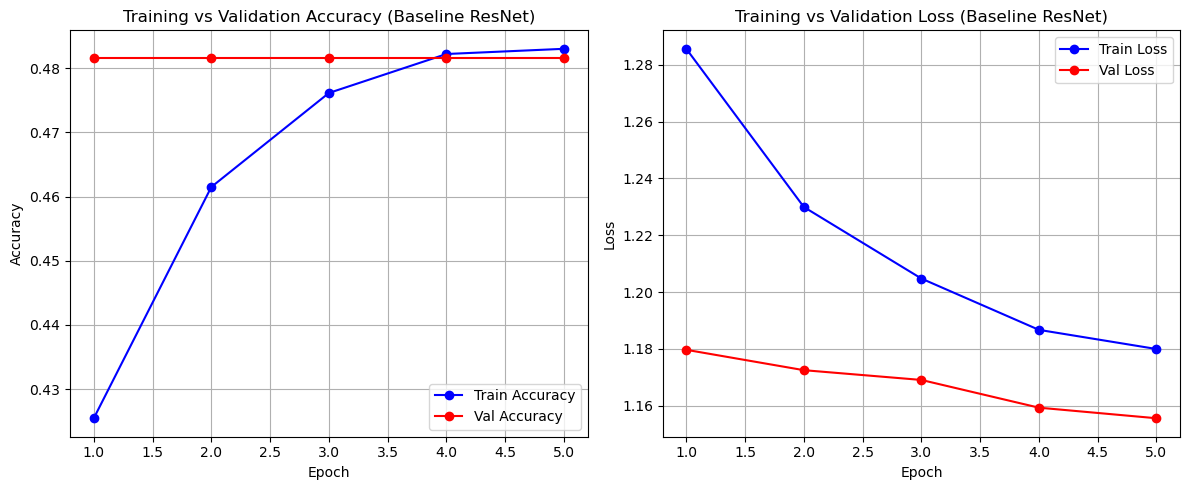

In [16]:
plot_training_curves(history)

# Classification Report

In [17]:
from sklearn.metrics import classification_report

print("Classification Report: Baseline ResNet")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report: Baseline ResNet
                 precision    recall  f1-score   support

          COVID       0.00      0.00      0.00       542
   Lung_Opacity       0.00      0.00      0.00       902
         Normal       0.48      1.00      0.65      1529
Viral_Pneumonia       0.00      0.00      0.00       202

       accuracy                           0.48      3175
      macro avg       0.12      0.25      0.16      3175
   weighted avg       0.23      0.48      0.31      3175



C:\Users\amysh\anaconda3.0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\amysh\anaconda3.0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\amysh\anaconda3.0\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Confusion Matrix

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)


[[   0    0  542    0]
 [   0    0  902    0]
 [   0    0 1529    0]
 [   0    0  202    0]]


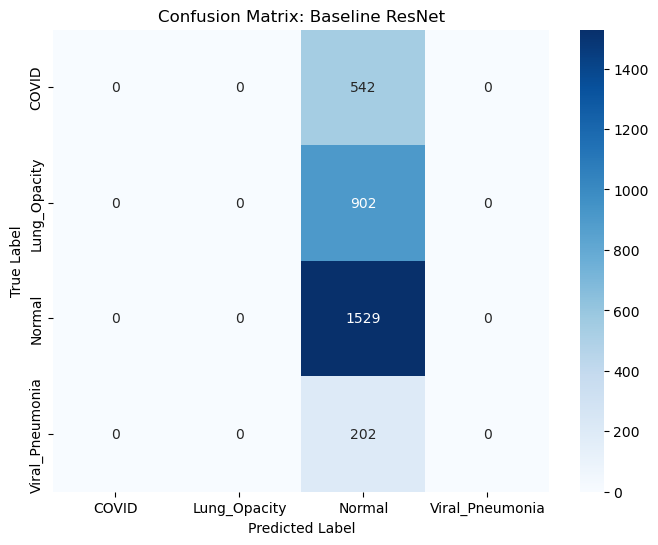

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Baseline ResNet")
plt.show()


# RoC-AuC Score

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_true_oh = label_binarize(y_true, classes=range(NUM_CLASSES))
print("Macro AUC:", roc_auc_score(y_true_oh, probs, average="macro", multi_class="ovr"))

Macro AUC: 0.6061385358169379


# Binarize labels for multiclass ROC

In [21]:
from sklearn.preprocessing import label_binarize

num_classes = probs.shape[1]

y_true_bin = label_binarize(
    y_true,
    classes=range(num_classes)
)



# Compute ROC & AUC

In [22]:
from sklearn.metrics import roc_curve, auc

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC

In [23]:
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes
macro_auc = auc(all_fpr, mean_tpr)


In [24]:
print(probs.shape)
print(y_true.shape)


(3175, 4)
(3175,)


# Plot ROC curve

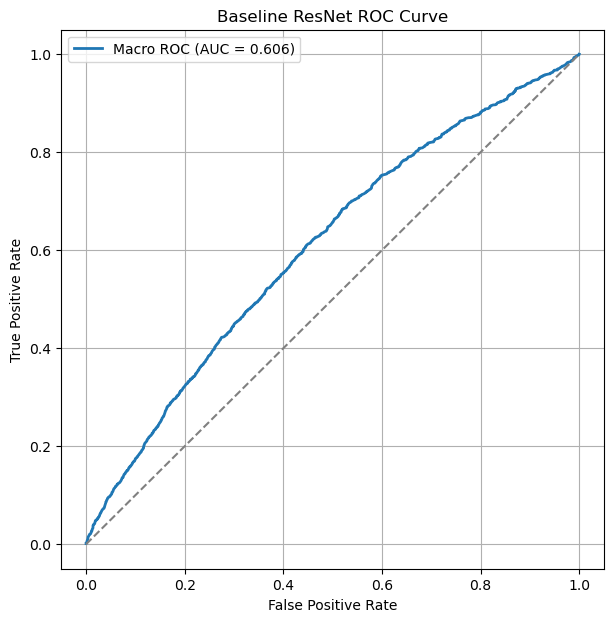

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.plot(all_fpr, mean_tpr,
         label=f"Macro ROC (AUC = {macro_auc:.3f})",
         linewidth=2)

plt.plot([0,1],[0,1],'--',color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline ResNet ROC Curve")
plt.legend()
plt.grid(True)
plt.show()
